In [ ]:
!rm -rf /content/dawn_dataset /content/dawn-yolo-format.zip /content/dawn.yaml

In [ ]:
# Download the public YOLO-formatted Foggy Cityscapes dataset
!kaggle datasets download -d khitdon/foggy-cityscapes-yolo

# Unzip it into a new folder
!unzip -q foggy-cityscapes-yolo.zip -d foggy_yolo

Dataset URL: https://www.kaggle.com/datasets/khitdon/foggy-cityscapes-yolo
License(s): unknown
100% 6.37G/6.37G [02:28<00:00, 46.0MB/s]



In [ ]:
import os

train_dir = ""
val_dir = ""

# Hunt down the exact folders containing the images
for root, dirs, files in os.walk('/content/foggy_yolo'):
    # Check if this folder actually contains image files
    if any(f.endswith(('.jpg', '.png', '.jpeg')) for f in files):
        if 'train' in root.lower():
            train_dir = root
        elif 'val' in root.lower() or 'valid' in root.lower():
            val_dir = root

if train_dir and val_dir:
    yaml_content = f"""
train: {train_dir}
val: {val_dir}

names:
  0: person
  1: rider
  2: car
  3: truck
  4: bus
  5: train
  6: motorcycle
  7: bicycle
"""
    with open("/content/foggy_yolo.yaml", "w") as f:
        f.write(yaml_content)
    print("✅ foggy_yolo.yaml auto-corrected successfully!")
    print(f"Mapped Train to: {train_dir}")
    print(f"Mapped Val to: {val_dir}")
else:
    print("❌ Could not find the image folders. Let's see what's inside:")
    import os
    os.system("ls -R /content/foggy_yolo | head -n 20")

✅ foggy_yolo.yaml auto-corrected successfully!
Mapped Train to: /content/foggy_yolo/YOLO_dataset_foggycityscapes/train/images
Mapped Val to: /content/foggy_yolo/YOLO_dataset_foggycityscapes/val/images


In [ ]:
# 1. Re-install the YOLO library
!pip install ultralytics -q

# 2. Import and start training
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/foggy_yolo.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    hsv_s=0.2,
    hsv_v=0.4,
    device=0
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 8.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/foggy_yolo.yaml, degrees=0.0, 

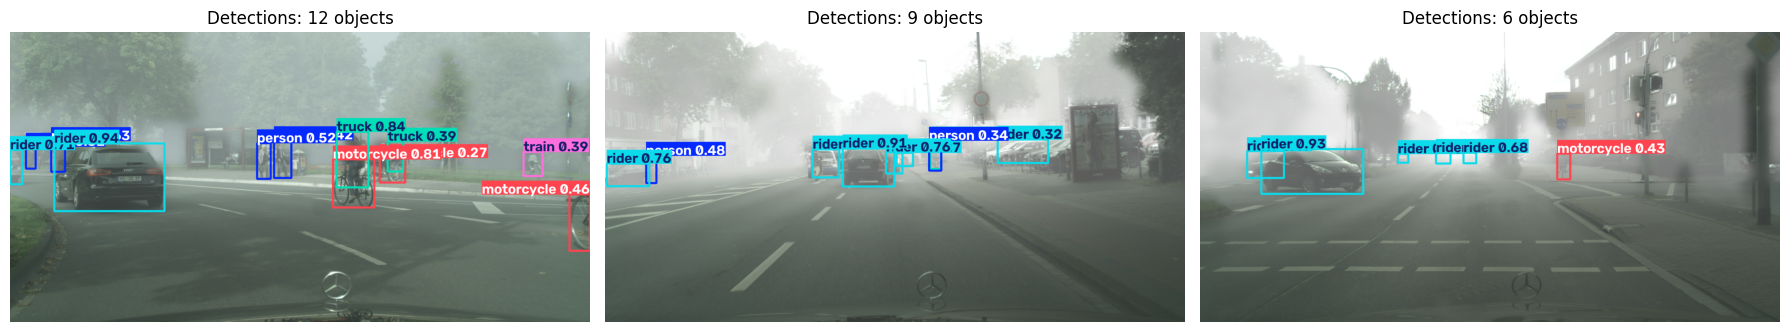

In [ ]:
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# 1. Load fine-tuned weights
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Pick random images from the existing validation split
val_images = glob.glob('/content/foggy_yolo/YOLO_dataset_foggycityscapes/val/images/*.*')
sample_paths = random.sample(val_images, 3)

# 3. Predict and visualize
plt.figure(figsize=(18, 6))

for i, img_path in enumerate(sample_paths):
    # Run inference (conf=0.25 threshold)
    results = model.predict(source=img_path, conf=0.25, save=False, verbose=False)

    # Render bounding boxes onto the image array (RGB)
    res_plotted = results[0].plot()

    # Display inline
    plt.subplot(1, 3, i + 1)
    plt.imshow(res_plotted[..., ::-1])  # Convert BGR to RGB
    plt.title(f"Detections: {len(results[0].boxes)} objects")
    plt.axis('off')

plt.tight_layout()
plt.show()